# REFCON quickstart

Reference-free per-gene **copy-number** inference from scRNA-seq. This notebook: installs the
package, fetches the released checkpoints + paired single-cell-DNA cohorts, runs REFCON on one
cohort (no reference/normal cells needed), scores it against paired scWGS, and visualizes the
per-cell copy-number calls. Runs on GPU, Apple MPS, or CPU.

## 1. Install
In Colab or a fresh clone, uncomment the clone line. `pip install -e .` reads `pyproject.toml`.

In [1]:
# !git clone https://github.com/gencturkmert/REFCON.git
# %cd REFCON
%pip install -e . --quiet
%pip install matplotlib --quiet   # for the plots in step 5

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## 2. Fetch checkpoints + data
Downloads the three ensemble checkpoints and the A375 / HCT116 cohorts from Zenodo
(no-op if already present).

In [2]:
import sys
!{sys.executable} scripts/fetch_data.py

[skip ] data/ already populated
[skip ] checkpoints/ already populated
done.


## 3. Run REFCON inference (reference-free)
Load one released checkpoint and infer per-gene CN ratios directly from expression.
The paper averages three checkpoints (`ens3`); one checkpoint is enough for a demo.

In [3]:
import numpy as np, torch, anndata as ad, scipy.sparse as sp
from refcon.model_binned_dev import BinnedDevModel
from refcon.eval_cellwide import get_chr_ranges, run_cellwide_inference, broadcast_bins_to_genes
from refcon.metrics import per_cell_metrics

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

ckpt = torch.load('checkpoints/baseline_bs8_mc1024.pt', map_location=device, weights_only=False)
cfg = ckpt['config']
model = BinnedDevModel(bin_size=cfg['bin_size'], max_chunk=cfg['max_chunk'],
                       d_model=cfg.get('d_model', 128), n_heads=cfg.get('n_heads', 4),
                       n_layers=cfg.get('n_layers', 4), dim_ff=cfg.get('dim_ff', 512), dropout=0.0).to(device)
model.load_state_dict(ckpt['model_state_dict']); model.eval()
print('checkpoint params:', f"{sum(p.numel() for p in model.parameters()):,}")

# HCT116 colorectal cohort (raw UMI) + paired scWGS ground truth
adata = ad.read_h5ad('data/hct116/hct116_dntr_per_cell.h5ad')
gt = np.load('data/hct116/hct116_dntr_per_cell_cn.npy')      # per-cell absolute CN, row-aligned
adata = adata[:96].copy(); gt = gt[:96]      # 96-cell demo (~1 min on a laptop); drop for all 1,468

X = adata.X; X = X.toarray() if sp.issparse(X) else np.asarray(X)
X_log = np.log1p(X.astype('float32'))        # REFCON input = log1p(raw UMI); no normalization
res = run_cellwide_inference(model, X_log, get_chr_ranges(adata), torch.device(device), cell_batch=8)
pred = broadcast_bins_to_genes(res['bin_profile'], res['bin_coords'], adata.n_vars)
print('predicted CN-ratio matrix:', pred.shape, '(per-cell mean approx. 1)')

device: mps


checkpoint params: 975,299


2026-07-28 20:37:56,240 [INFO]   23 chr-internal windows (stride=512, div=2)


2026-07-28 20:38:08,234 [INFO]   chr-internal bidir forward: 12.0s


2026-07-28 20:38:08,244 [INFO]   53 bridge windows (stride=256, div=4)


2026-07-28 20:38:33,214 [INFO]   bridge bidir forward: 25.0s


2026-07-28 20:38:33,696 [INFO]   cellwide_direct joint LSQ: 0.5s  (1555 global bins)


predicted CN-ratio matrix: (96, 12506) (per-cell mean approx. 1)


## 4. Score against paired single-cell DNA
The paper's exact per-cell metric (`refcon.metrics.per_cell_metrics`).

In [4]:
m = per_cell_metrics(pred, gt.astype(float), fill_diploid=True)
print(f'per-cell Pearson = {np.nanmean(m.P):.3f}')
print(f'per-cell AUROC   = loss {np.nanmean(m.AL):.3f} | gain {np.nanmean(m.AG):.3f}')

per-cell Pearson = 0.364
per-cell AUROC   = loss 0.693 | gain 0.811


## 5. Per-cell copy-number heatmap vs ground truth
Every cell's genome-wide profile, binned along the genome, next to its paired single-cell DNA. REFCON's predicted gains/losses should line up with the same genomic bands in the DNA.

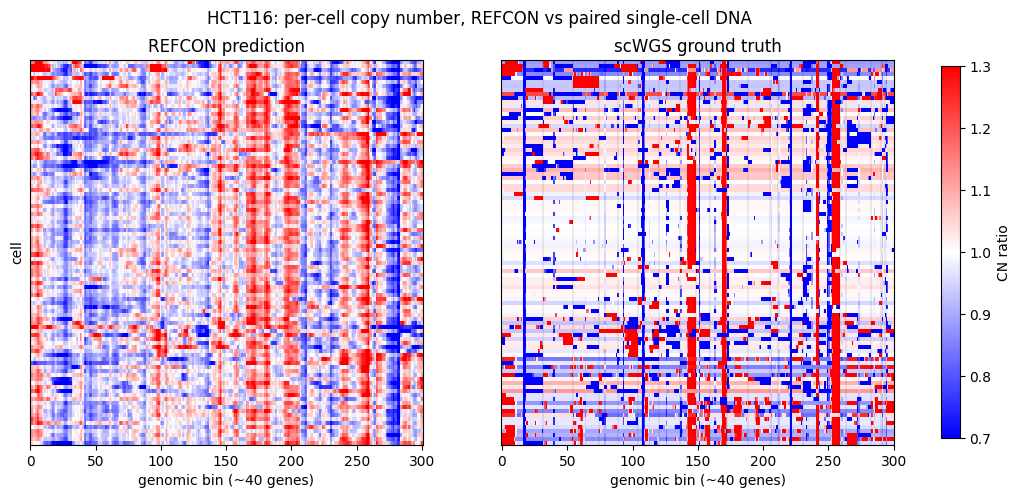

In [5]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

def bin_genome(M, chrom, chr_order, per_bin=40):
    """Average consecutive genes into fixed genomic bins within each chromosome; renormalize each cell to mean 1."""
    M = np.asarray(M, float); cols, bnds = [], []
    for ch in chr_order:
        cidx = np.where(chrom == ch)[0]; nb_ = max(1, len(cidx) // per_bin)
        edges = np.linspace(0, len(cidx), nb_ + 1).astype(int)
        for i in range(nb_):
            with np.errstate(all="ignore"):
                cols.append(np.nanmean(M[:, cidx[edges[i]:edges[i+1]]], axis=1))
        bnds.append(len(cols))
    B = np.column_stack(cols)
    B = np.where(np.isfinite(B), B, np.nanmean(B, axis=1, keepdims=True))
    return B / np.nanmean(B, axis=1, keepdims=True), np.array(bnds[:-1])

def genome_axes(adata_):
    go = np.argsort(adata_.var["abspos"].values)
    ch = adata_.var["chromosome"].astype(str).values[go]
    _, first = np.unique(ch, return_index=True)
    return go, ch, ch[np.sort(first)]

go, chrom, chr_order = genome_axes(adata)
gt_ratio = np.where(gt >= 0, gt.astype(float), np.nan)[:, go]
Mp, chrbnd = bin_genome(pred[:, go], chrom, chr_order)
Mg, _      = bin_genome(gt_ratio,    chrom, chr_order)
cell_order = leaves_list(linkage(np.nan_to_num(Mg, nan=1.0), method="ward"))  # group similar cells
Mp, Mg = Mp[cell_order], Mg[cell_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (title, M) in zip(axes, [("REFCON prediction", Mp), ("scWGS ground truth", Mg)]):
    im = ax.imshow(M, aspect="auto", cmap="bwr", vmin=0.7, vmax=1.3, interpolation="nearest")
    for b in chrbnd: ax.axvline(b - 0.5, color="k", lw=0.3, alpha=0.35)
    ax.set(title=title, xlabel="genomic bin (~40 genes)"); ax.set_yticks([])
axes[0].set_ylabel("cell")
fig.colorbar(im, ax=axes, fraction=0.02, label="CN ratio")
fig.suptitle("HCT116: per-cell copy number, REFCON vs paired single-cell DNA")
plt.show()

## 6. Reference refinement with a self-detected diploid anchor
REFCON is reference-free, but when a sample contains normal cells it can *refine* the tumor profiles. On a scONE-seq glioblastoma with paired scWGS, REFCON detects its own diploid anchor from expression (no labels), then refines tumor copy number against it. This is the Section 2.5 self-detected pipeline; Section 2.2 instead refines against author-annotated reference cells.

In [6]:
import subprocess, os
# Full 3-checkpoint ensemble on all 840 scONE cells. Idempotent: skips if already computed.
if not os.path.exists("out/scone/ens3_cn.npz"):
    subprocess.run([sys.executable, "scripts/infer.py", "--data", "data/scone/scone_astrocytoma.h5ad",
                    "--out", "out/scone", "--device", device], check=True)
else:
    print("using existing out/scone/ens3_cn.npz")

sc = ad.read_h5ad("data/scone/scone_astrocytoma.h5ad")
npz = np.load("out/scone/ens3_cn.npz", allow_pickle=True)
cn = np.asarray(npz["cn"], float)                                   # (840, genes) reference-free ens3
pos = {n: i for i, n in enumerate(sc.obs_names.astype(str))}
rowi = np.array([pos[c] for c in npz["cells"].astype(str)])         # align npz rows to h5ad obs order
role  = sc.obs["cn_role"].astype(str).values[rowi]
clone = sc.obs["Clone_type"].astype(str).values[rowi]
gt_sc  = np.load("data/scone/scone_astrocytoma_cn.npy")[rowi].astype(float)
counts = (sc.X.toarray() if sp.issparse(sc.X) else np.asarray(sc.X))[rowi]
genes_sc = sc.var_names.astype(str).values
tumor = role == "tumor"
print(f"scONE ens3 CN {cn.shape} | tumor {int(tumor.sum())} | reference {int((role=='reference').sum())}")

using existing out/scone/ens3_cn.npz


scONE ens3 CN (840, 14509) | tumor 390 | reference 450


### Detect diploid cells from expression (no labels)
REFCON's confident-diploid detector (a marker-enrichment test on expression) flags the normal cells; these become the self-detected refinement anchor.

In [7]:
from refcon.downstream.markers import ssmww_confident_normal

det = ssmww_confident_normal(counts, genes_sc)
normal = det["norm_mask"]                                           # self-detected diploid cells
rec = int((normal & (role == "reference")).sum())
print(f"detected {det['n_confident']} diploid cells: "
      f"{rec} are annotated reference cells, {int((normal & tumor).sum())} tumor "
      f"(precision {rec / max(det['n_confident'], 1):.0%})")

detected 61 diploid cells: 60 are annotated reference cells, 1 tumor (precision 98%)


### Refine the tumor profiles and score against paired DNA

In [8]:
from refcon.refine import calibrate_predictions

cn_refined = calibrate_predictions(cn, normal, svd_k=3)             # refine against the self-detected anchor
p_free = np.nanmean(per_cell_metrics(cn[tumor],        gt_sc[tumor]).P)
p_ref  = np.nanmean(per_cell_metrics(cn_refined[tumor], gt_sc[tumor]).P)
print(f"tumor per-cell Pearson: reference-free {p_free:.3f}  ->  refined {p_ref:.3f}")

/Users/mertgencturk/Library/Mobile Documents/com~apple~CloudDocs/scrna/refcon/refcon/refine.py:93: RuntimeWarning: Mean of empty slice
  bias = np.nanmean(refs, axis=0) - 1.0


tumor per-cell Pearson: reference-free 0.392  ->  refined 0.509


### Per-cell heatmap: reference-free vs refined vs ground truth
Tumor cells grouped by clone. Glioblastoma copy number is subtle, so the refinement gain is clearest in the Pearson above; the ground-truth panel shows the structure REFCON recovers.

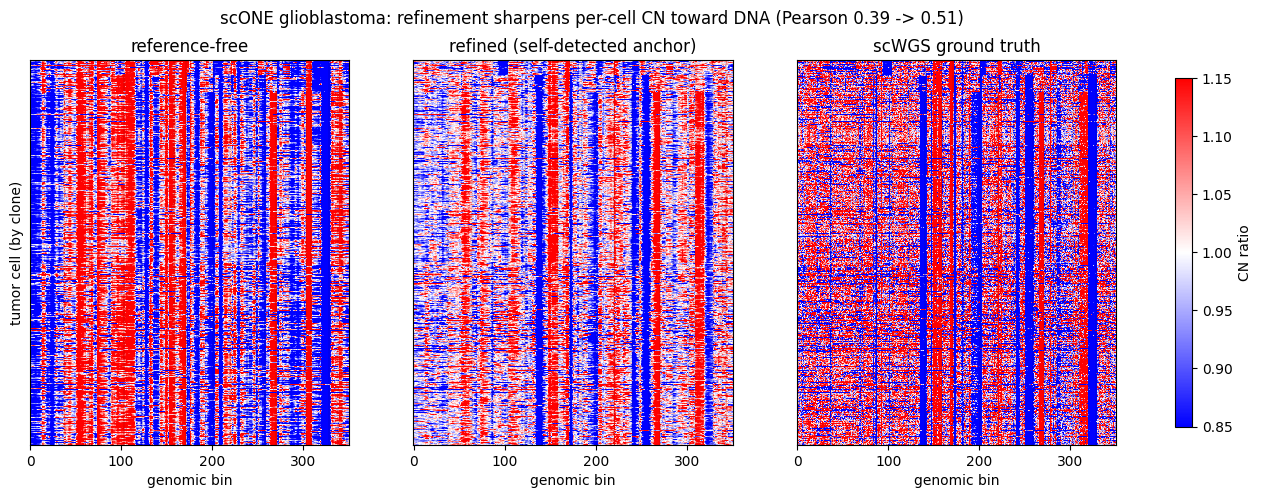

In [9]:
go2, chrom2, chr_order2 = genome_axes(sc)
tix = np.where(tumor)[0]; tix = tix[np.argsort(clone[tix])]        # tumor cells grouped by clone
gtt = np.where(gt_sc[tix] >= 0, gt_sc[tix], np.nan)[:, go2]
Mf, cb = bin_genome(cn[tix][:, go2],         chrom2, chr_order2)
Mr, _  = bin_genome(cn_refined[tix][:, go2], chrom2, chr_order2)
Mg2, _ = bin_genome(gtt,                      chrom2, chr_order2)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, (title, M) in zip(axes, [("reference-free", Mf),
                                  ("refined (self-detected anchor)", Mr),
                                  ("scWGS ground truth", Mg2)]):
    im = ax.imshow(M, aspect="auto", cmap="bwr", vmin=0.85, vmax=1.15, interpolation="nearest")
    for b in cb: ax.axvline(b - 0.5, color="k", lw=0.3, alpha=0.35)
    ax.set(title=title, xlabel="genomic bin"); ax.set_yticks([])
axes[0].set_ylabel("tumor cell (by clone)")
fig.colorbar(im, ax=axes, fraction=0.015, label="CN ratio")
fig.suptitle(f"scONE glioblastoma: refinement sharpens per-cell CN toward DNA "
             f"(Pearson {p_free:.2f} -> {p_ref:.2f})")
plt.show()

## Next steps
- **Full cohort + released ensemble (paper numbers):**
  `python scripts/infer.py --data data/hct116/hct116_dntr_per_cell.h5ad --out out/hct116`
  averages all three checkpoints over all 1,468 cells, then score with
  `python scripts/score.py --pred out/hct116/ens3_cn.npz --gt data/hct116/hct116_dntr_per_cell_cn.npy`.
- **A375:** swap the paths to `data/a375/a375_dntr_per_cell*`.
- **Your own data:** any `.h5ad` with raw UMI in `X` and `var` carrying `chromosome` / `start` / `end` /
  `chr_boundary` (see `docs/input_format.md`). Reference-free; no normal cells required.